In [1]:
from constants import users_list, data_path
from lib import spoti, genre_normalizer, plotting, preprocessing, dimensionality_reduction, user_similarities

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import json
import os
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.nn import functional as F
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import mean_squared_error
import random
import time
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors, NeighborhoodComponentsAnalysis
from sklearn.metrics import pairwise_distances
import pickle
import numpy as np
from typing import List, Dict, Tuple, Optional, Any, Callable
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from IPython.display import display, HTML
from lib.matrix_dataset import MatrixDataset
from recommenders.vae import MultiVAE
from recommenders.metrics import NDCG_binary_at_k_batch, Recall_at_k_batch_torch, mpr
import datetime
from recommenders.lmf import LogisticMatrixFactorization

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    device = mps_device
    x = torch.ones(1, device=mps_device)
    print(x)
else:
    print ("MPS device not found.")

if device == torch.device("cuda"):
    dtype = torch.float32
    print("Using CUDA.")
elif device == torch.device("cpu"):
    dtype = torch.float64
    print("Using CPU.")
elif device == torch.device("mps"):
    dtype = torch.float32
    print("Using MPS.")

# device = "cpu"
# dtype = torch.float32

tensor([1.], device='mps:0')
Using MPS.


# Import data

In [3]:
df = spoti.load_all_tracks(
    base_path=data_path.DATA_PATH,
    users=users_list.USERS,
    load_spotify_tracks=False,
    penality_factors={"short_term": 1, "medium_term": 1, "long_term": 1},
)
df

,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,time_range,affinity,username,release_year,normalized_genres,added_at,episode,track,added_by,playlist_id
0,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,196426,False,{'isrc': 'USSM12301260'},{'spotify': 'https://open.spotify.com/track/75...,https://api.spotify.com/v1/tracks/75rqqKvzJCGv...,75rqqKvzJCGv2oq9C4yFDt,...,medium_term,1.00,jaslkh,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
1,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,137533,True,{'isrc': 'USSM12109218'},{'spotify': 'https://open.spotify.com/track/2F...,https://api.spotify.com/v1/tracks/2FYGZDfsAnNs...,2FYGZDfsAnNsrm1gVbyKnG,...,medium_term,0.98,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
2,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,162906,True,{'isrc': 'USSM12109222'},{'spotify': 'https://open.spotify.com/track/4k...,https://api.spotify.com/v1/tracks/4kroNlz8BTfs...,4kroNlz8BTfswE4M0i3YCh,...,medium_term,0.96,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
3,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,89749,False,{'isrc': 'USSM12208854'},{'spotify': 'https://open.spotify.com/track/2N...,https://api.spotify.com/v1/tracks/2N3YZ075lq9z...,2N3YZ075lq9z1ObaAiX6l1,...,medium_term,0.94,jaslkh,2022,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
4,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,174044,False,{'isrc': 'USSM12300114'},{'spotify': 'https://open.spotify.com/track/2S...,https://api.spotify.com/v1/tracks/2SiAcexM2p1y...,2SiAcexM2p1yX6joESbehd,...,medium_term,0.92,jaslkh,2023,"[spanish, pop, rnb]",NaT,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12424,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,251880,False,{'isrc': 'GBN9Y1100001'},{'spotify': 'https://open.spotify.com/track/3z...,https://api.spotify.com/v1/tracks/3z7dWKRsjDNM...,3z7dWKRsjDNM24ohLKZBnA,...,NaN,NaN,dany,1967,"[rock, rock, rock, rock, rock, rock, rock]",2022-12-30 08:42:31+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12425,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,193853,False,{'isrc': 'GBLTP1700005'},{'spotify': 'https://open.spotify.com/track/1V...,https://api.spotify.com/v1/tracks/1VofMhhL98pe...,1VofMhhL98pewltVGBSmCW,...,NaN,NaN,dany,2017,"[rock, rock, rock, rock, rock]",2020-08-10 14:53:07+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12426,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,295493,False,{'isrc': 'GBLTP1700011'},{'spotify': 'https://open.spotify.com/track/0K...,https://api.spotify.com/v1/tracks/0KE7apgczHNY...,0KE7apgczHNYiXIvMUY0Fc,...,NaN,NaN,dany,2017,"[rock, rock, rock, rock, rock]",2020-08-10 14:53:13+00:00,False,True,ssscnm71jg9pv7fryho4d5qgs,674vFKUXNUjlUxXhAnQvG9
12427,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,467306,False,{'isrc': 'GBLTP1700014'},{'spotify': 'https://open.spotify.com/track/6v...,https://api.spotify.com/v1/tracks/6vbRA9yAAgIX...,6vbRA9yAAgIXtDlmhyNqPq,...,NaN,N

In [4]:
df = pd.read_csv(os.path.join(data_path.DATA_PATH, "artificial_data.csv"), index_col=0)
df["type"] = "top_track"
df

,id,username,danceability,duration_ms,instrumentalness,affinity,type
0,Skill,Matthew Valencia,0.168972,0.393010,0.107700,0.277396,top_track
1,Simply some,Matthew Valencia,0.602153,0.281286,0.360737,0.305182,top_track
2,Practice,Matthew Valencia,0.102147,0.214526,0.117687,0.392138,top_track
3,Product,Matthew Valencia,0.071125,0.080618,0.131655,0.108841,top_track
4,Professional,Matthew Valencia,0.429718,0.285770,0.298749,0.086235,top_track
...,...,...,...,...,...,...,...
49995,Church life,Michael Ramirez Jr.,0.167156,0.393468,0.174675,0.099820,top_track
49996,Couple leave,Michael Ramirez Jr.,0.596482,0.009788,0.066215,0.061900,top_track
49997,Reason early,Michael Ramirez Jr.,0.046132,0.186828,0.395730,0.033652,top_track
49998,One send from,Michael Ramirez Jr.,0.315609,0.304490,0.579923,0.100289,top_track


In [5]:
# df = pd.read_csv(os.path.join(data_path.DATA_PATH, "ratings.csv"))
# df["type"] = "top_track"
# df.columns = ["username", "id", "affinity", "timestamp", "type"]
# df

## Setup the dataset

In [6]:
df_matrix_mf = df.copy()
df_matrix_mf.drop_duplicates(subset=["username", "id"], inplace=True) # A user can have multiple entries for the same track (if it's in multiple playlists)
df_matrix_mf.loc[df_matrix_mf["type"] == "liked_track", "affinity"] = 0.5
df_matrix_mf.loc[df_matrix_mf["type"] == "playlist", "affinity"] = 0.3

used_types = ["top_track", "liked_track", "playlist"]
# used_types = ["top_track"]
df_matrix_mf = df_matrix_mf[df["type"].isin(used_types)]
df_matrix_mf["id"] = df_matrix_mf["id"].astype("category")
df_matrix_mf["username"] = df_matrix_mf["username"].astype("category")
df_matrix_mf

/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_52629/1256999401.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_matrix_mf = df_matrix_mf[df["type"].isin(used_types)]


,id,username,danceability,duration_ms,instrumentalness,affinity,type
0,Skill,Matthew Valencia,0.168972,0.393010,0.107700,0.277396,top_track
1,Simply some,Matthew Valencia,0.602153,0.281286,0.360737,0.305182,top_track
2,Practice,Matthew Valencia,0.102147,0.214526,0.117687,0.392138,top_track
3,Product,Matthew Valencia,0.071125,0.080618,0.131655,0.108841,top_track
4,Professional,Matthew Valencia,0.429718,0.285770,0.298749,0.086235,top_track
...,...,...,...,...,...,...,...
49995,Church life,Michael Ramirez Jr.,0.167156,0.393468,0.174675,0.099820,top_track
49996,Couple leave,Michael Ramirez Jr.,0.596482,0.009788,0.066215,0.061900,top_track
49997,Reason early,Michael Ramirez Jr.,0.046132,0.186828,0.395730,0.033652,top_track
49998,One send from,Michael Ramirez Jr.,0.315609,0.304490,0.579923,0.100289,top_track


In [7]:
df_matrix_mf_filtered = preprocessing.filter_rows_by_min_number_of_occurence(df_matrix_mf, "id", 5)
df_matrix_mf_filtered

,id,username,danceability,duration_ms,instrumentalness,affinity,type
0,Skill,Matthew Valencia,0.168972,0.393010,0.107700,0.277396,top_track
2,Practice,Matthew Valencia,0.102147,0.214526,0.117687,0.392138,top_track
3,Product,Matthew Valencia,0.071125,0.080618,0.131655,0.108841,top_track
4,Professional,Matthew Valencia,0.429718,0.285770,0.298749,0.086235,top_track
5,Science,Matthew Valencia,0.241306,0.487671,0.013941,0.035955,top_track
...,...,...,...,...,...,...,...
49967,Development,Michael Ramirez Jr.,0.414536,0.622205,0.133733,0.311688,top_track
49976,Develop,Michael Ramirez Jr.,0.009332,0.226275,0.110813,0.106131,top_track
49988,Those,Michael Ramirez Jr.,0.388500,0.210608,0.318733,0.200187,top_track
49990,Protect,Michael Ramirez Jr.,0.483449,0.092080,0.302563,0.360458,top_track


In [8]:
sparsity, users_count, items_count, interactions_count = preprocessing.compute_sparsity(df_matrix_mf_filtered, "username", "id")
print(f"After filtering, there is {len(users_count)} users, {len(items_count)} items and {len(interactions_count)} interactions, so the sparsity is {sparsity*100:.2f}%.")

After filtering, there is 100 users, 39300 items and 7627 interactions, so the sparsity is 0.19%.


In [9]:
df_matrix_mf_filtered["id"] = df_matrix_mf_filtered["id"].cat.remove_unused_categories()
df_matrix_mf_filtered["username"] = df_matrix_mf_filtered["username"].cat.remove_unused_categories()

/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_52629/3495685520.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matrix_mf_filtered["id"] = df_matrix_mf_filtered["id"].cat.remove_unused_categories()
/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_52629/3495685520.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_matrix_mf_filtered["username"] = df_matrix_mf_filtered["username"].cat.remove_unused_categories()


In [10]:
display(users_count)
shuffled_users_df = preprocessing.permute_users(users_count=users_count, seed=42)
display(shuffled_users_df)

username
Paul Fitzpatrick     93
Christina Leonard    90
Joseph Miller        90
Anthony Schwartz     89
Antonio Perry        89
                     ..
Melinda Bradley      63
Steven White         62
Robert Santos        60
Zachary Sparks       60
Mitchell Jensen      57
Name: count, Length: 100, dtype: int64

,count,old_index
username,,
Morgan Gallagher,69,Morgan Gallagher
Cheryl Wise,76,Cheryl Wise
Carl Williams,72,Carl Williams
Hayden Moody,77,Hayden Moody
John Martinez,77,John Martinez
...,...,...
Brian Bowman,74,Brian Bowman
Matthew Thompson,72,Matthew Thompson
Tara Barry,84,Tara Barry


In [11]:
train_df, val_df, test_df = preprocessing.split_users_train_validation_test(df_users_shuffled=shuffled_users_df, validation_percentage=0.2, test_percentage=0.2)
print("Original data:")
display(shuffled_users_df)
print("Train data:")
display(train_df)
print("Validation data:")
display(val_df)
print("Test data:")
display(test_df)

Original data:


,count,old_index
username,,
Morgan Gallagher,69,Morgan Gallagher
Cheryl Wise,76,Cheryl Wise
Carl Williams,72,Carl Williams
Hayden Moody,77,Hayden Moody
John Martinez,77,John Martinez
...,...,...
Brian Bowman,74,Brian Bowman
Matthew Thompson,72,Matthew Thompson
Tara Barry,84,Tara Barry


Train data:


,count,old_index
username,,
Morgan Gallagher,69,Morgan Gallagher
Cheryl Wise,76,Cheryl Wise
Carl Williams,72,Carl Williams
Hayden Moody,77,Hayden Moody
John Martinez,77,John Martinez
...,...,...
Amy Daniels,67,Amy Daniels
Patricia Davis,75,Patricia Davis
Mitchell Jensen,57,Mitchell Jensen


Validation data:


,count,old_index
username,,
Ashley Clark,76,Ashley Clark
Mr. John Vazquez,72,Mr. John Vazquez
Angela Harrington,77,Angela Harrington
Victoria Goodwin,72,Victoria Goodwin
Kim Woods,74,Kim Woods
Robert Santos,60,Robert Santos
Ann Keller,71,Ann Keller
Matthew Valencia,78,Matthew Valencia
Micheal Collier,74,Micheal Collier


Test data:


,count,old_index
username,,
Gregory Snyder,73,Gregory Snyder
Russell Schmidt,69,Russell Schmidt
Karen Dunn,79,Karen Dunn
Sandra Richardson,81,Sandra Richardson
Christina Leonard,90,Christina Leonard
Julia Owens,76,Julia Owens
Patrick Simon,82,Patrick Simon
Joseph Miller,90,Joseph Miller
Dr. Joseph Medina,82,Dr. Joseph Medina


Train data:


,id,username,danceability,duration_ms,instrumentalness,affinity,type
1004,Daughter,Dillon Davis,0.161563,0.061371,0.406949,0.188829,top_track
1016,Effect,Dillon Davis,0.362256,0.392515,0.023301,0.339204,top_track
1030,Possible,Dillon Davis,0.244740,0.019267,0.108546,0.107206,top_track
1036,Reflect,Dillon Davis,0.355468,0.257045,0.308013,0.385213,top_track
1045,Certainly,Dillon Davis,0.633400,0.342172,0.198735,0.470082,top_track
...,...,...,...,...,...,...,...
49967,Development,Michael Ramirez Jr.,0.414536,0.622205,0.133733,0.311688,top_track
49976,Develop,Michael Ramirez Jr.,0.009332,0.226275,0.110813,0.106131,top_track
49988,Those,Michael Ramirez Jr.,0.388500,0.210608,0.318733,0.200187,top_track
49990,Protect,Michael Ramirez Jr.,0.483449,0.092080,0.302563,0.360458,top_track


Validation train data:


,id,username,danceability,duration_ms,instrumentalness,affinity,type
39526,Region,Angela Harrington,0.106664,0.189367,0.213917,0.324607,top_track
39530,Relationship,Angela Harrington,0.648967,0.395885,0.165572,0.296080,top_track
39538,Environmental,Angela Harrington,0.918319,0.350765,0.013780,0.500733,top_track
39543,Company,Angela Harrington,0.105245,0.176931,0.006700,0.180756,top_track
39548,Community,Angela Harrington,0.035986,0.186405,0.478971,0.474199,top_track
...,...,...,...,...,...,...,...
42424,Response,Zachary Sparks,0.142078,0.357769,0.406709,0.094100,top_track
42431,Opportunity,Zachary Sparks,0.097397,0.004592,0.010200,0.021597,top_track
42455,Citizen,Zachary Sparks,0.327590,0.153620,0.134426,0.116815,top_track
42473,Building,Zachary Sparks,0.032478,0.589925,0.095236,0.101081,top_track


Validation test data:


,id,username,danceability,duration_ms,instrumentalness,affinity,type
39502,Military,Angela Harrington,0.232365,0.041827,0.673525,0.215802,top_track
39514,Brother,Angela Harrington,0.589471,0.410157,0.172296,0.003377,top_track
39528,Production,Angela Harrington,0.009911,0.221291,0.214356,0.187867,top_track
39551,Today,Angela Harrington,0.158901,0.207189,0.317606,0.257194,top_track
39601,Reveal,Angela Harrington,0.128667,0.429896,0.058185,0.253524,top_track
...,...,...,...,...,...,...,...
42428,Official,Zachary Sparks,0.680131,0.244488,0.170895,0.090980,top_track
42432,Animal,Zachary Sparks,0.384463,0.159128,0.404576,0.134535,top_track
42474,Authority,Zachary Sparks,0.367407,0.216970,0.113760,0.188085,top_track
42484,Increase,Zachary Sparks,0.072703,0.431228,0.189193,0.055449,top_track


Test train data:


,id,username,danceability,duration_ms,instrumentalness,affinity,type
36501,Response,Brian Bowman,0.525343,0.134806,0.353491,0.548244,top_track
36504,Might,Brian Bowman,0.230812,0.280174,0.114856,0.162932,top_track
36515,Address,Brian Bowman,0.150142,0.012462,0.027371,0.151309,top_track
36533,Include,Brian Bowman,0.167122,0.412076,0.046513,0.856710,top_track
36541,Attack,Brian Bowman,0.087214,0.445434,0.169560,0.043181,top_track
...,...,...,...,...,...,...,...
20423,Better,Tracy Jones,0.349622,0.021725,0.038478,0.115300,top_track
20435,Choice,Tracy Jones,0.306906,0.008549,0.258798,0.266810,top_track
20441,Remember,Tracy Jones,0.089152,0.188298,0.171416,0.211492,top_track
20462,Hospital,Tracy Jones,0.081287,0.011631,0.061897,0.564071,top_track


Test test data:


,id,username,danceability,duration_ms,instrumentalness,affinity,type
36522,Reduce,Brian Bowman,0.146297,0.656406,0.282283,0.168997,top_track
36568,Wonder,Brian Bowman,0.452974,0.549169,0.082693,0.321236,top_track
36578,Product,Brian Bowman,0.106971,0.259117,0.068152,0.604284,top_track
36579,Collection,Brian Bowman,0.309081,0.126698,0.018997,0.065942,top_track
36589,Service,Brian Bowman,0.508004,0.191994,0.469540,0.363605,top_track
...,...,...,...,...,...,...,...
20369,Traditional,Tracy Jones,0.285952,0.471030,0.464211,0.013627,top_track
20385,Specific,Tracy Jones,0.272038,0.093771,0.241091,0.241619,top_track
20424,Position,Tracy Jones,0.037915,0.223428,0.096207,0.442901,top_track
20471,Western,Tracy Jones,0.249265,0.436692,0.066484,0.000506,top_track


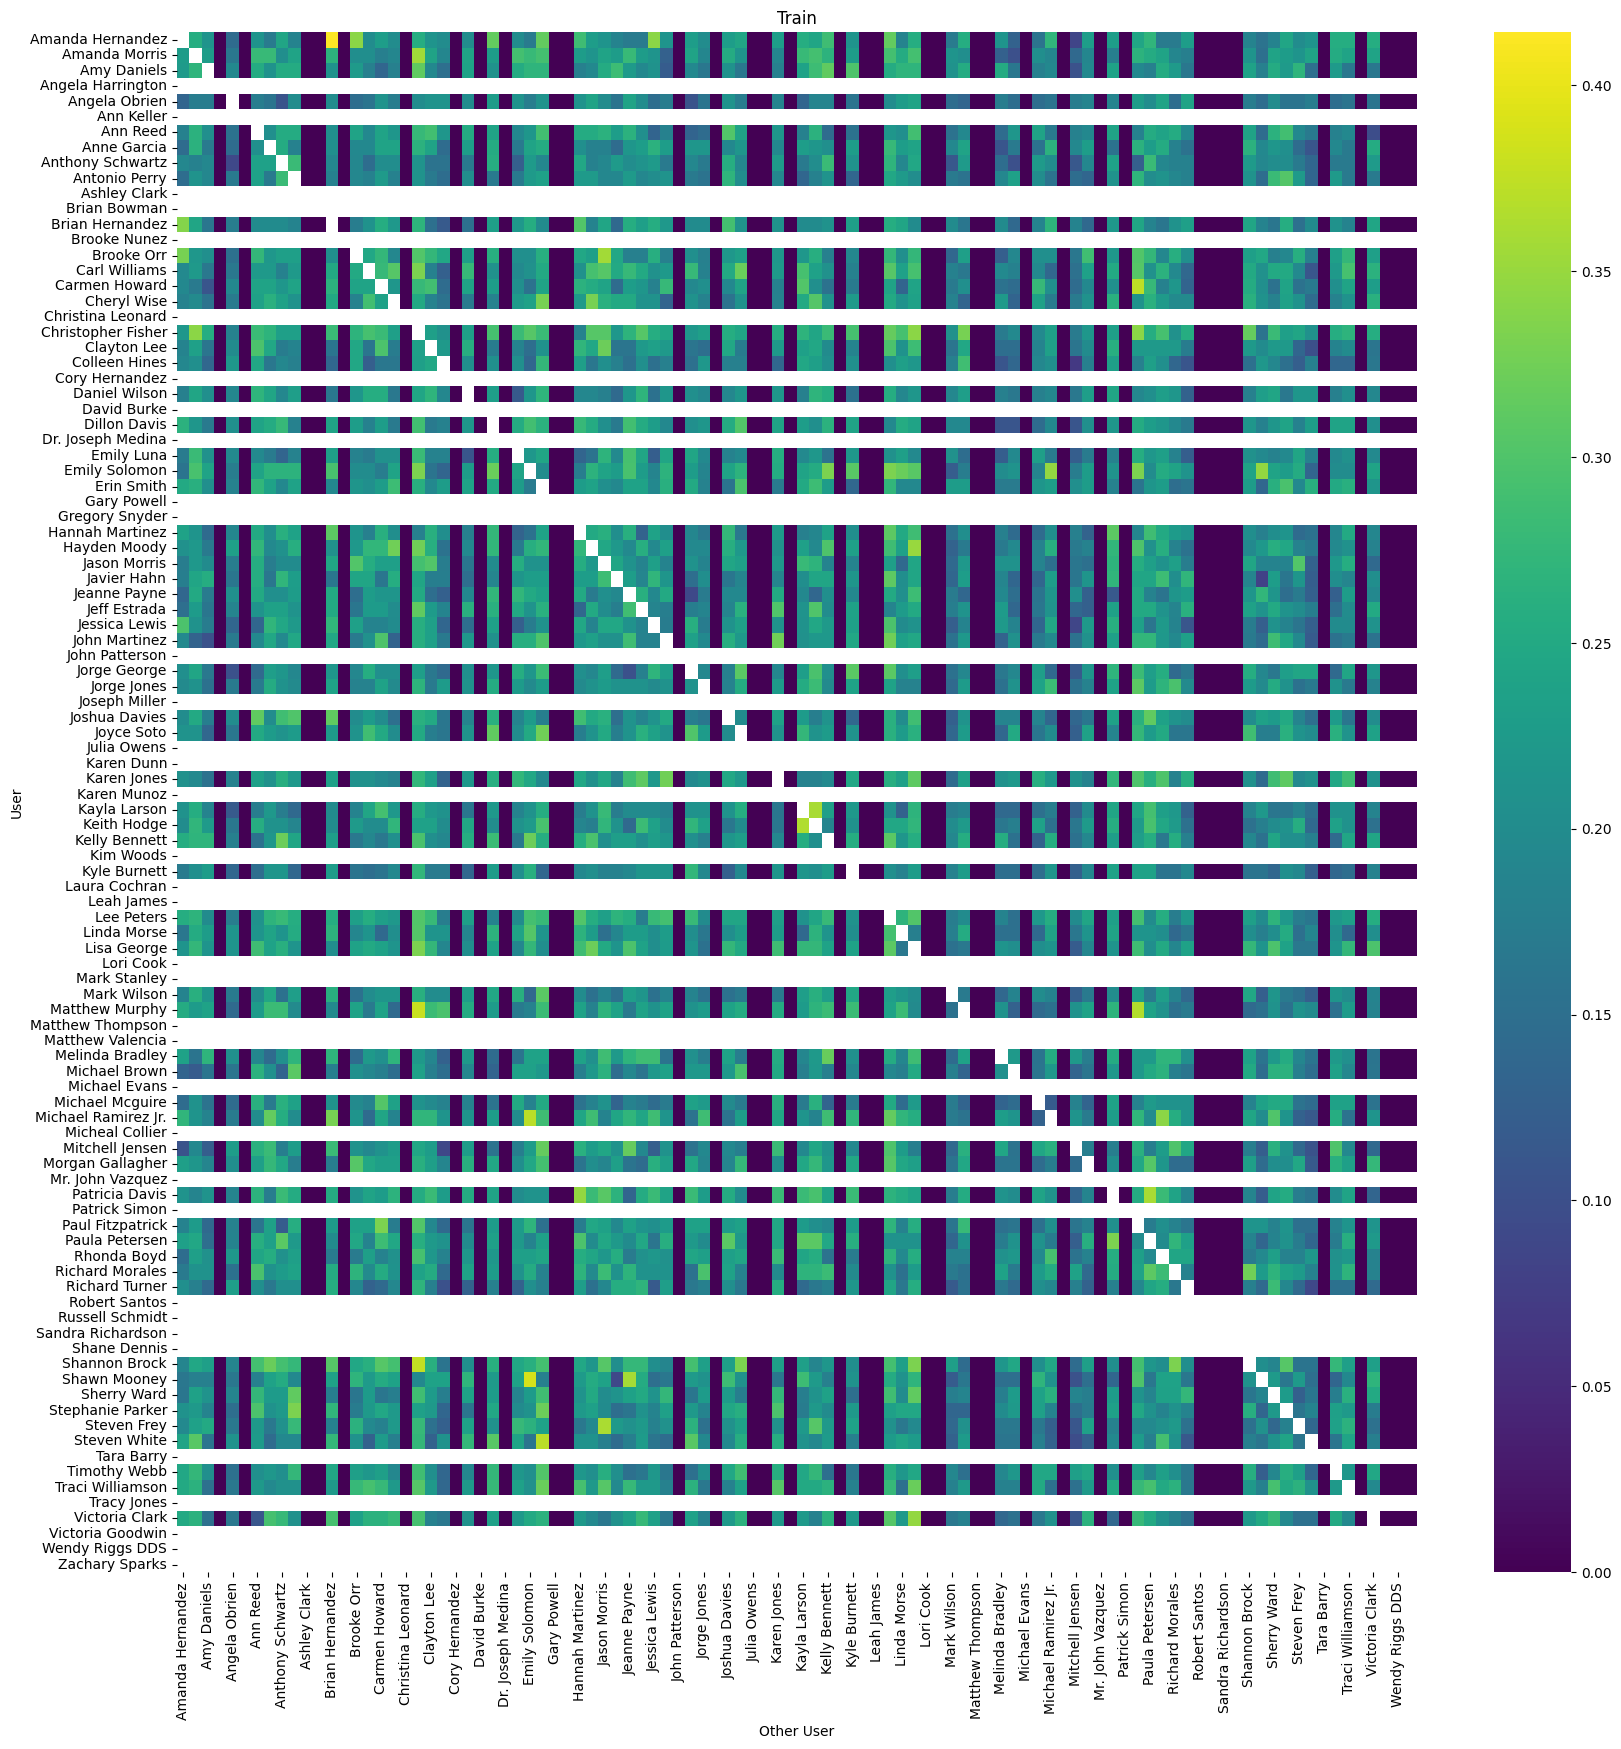

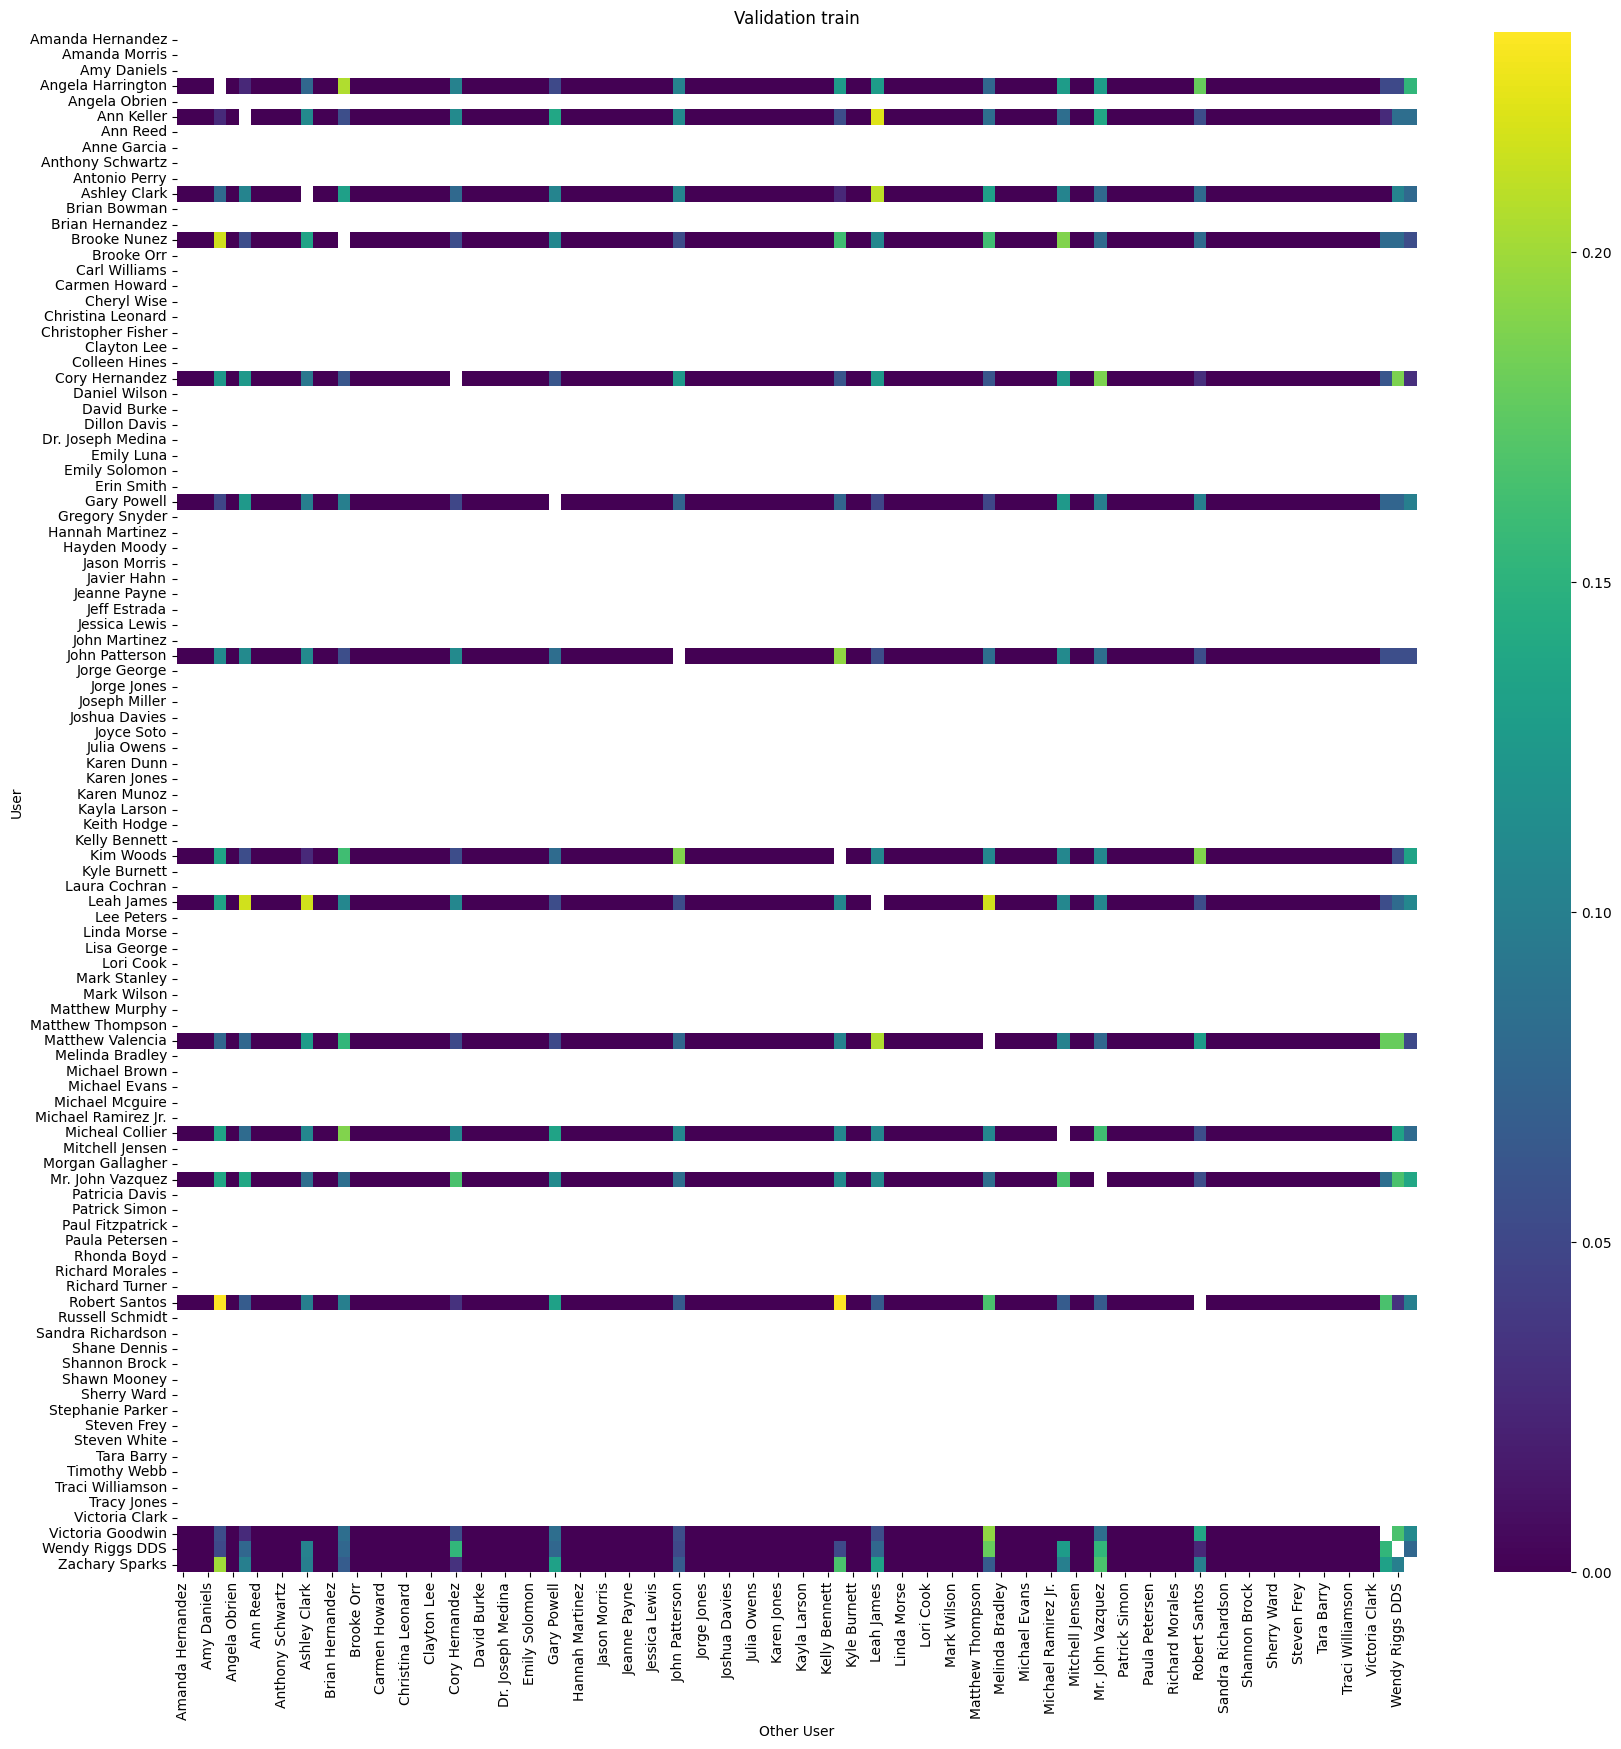

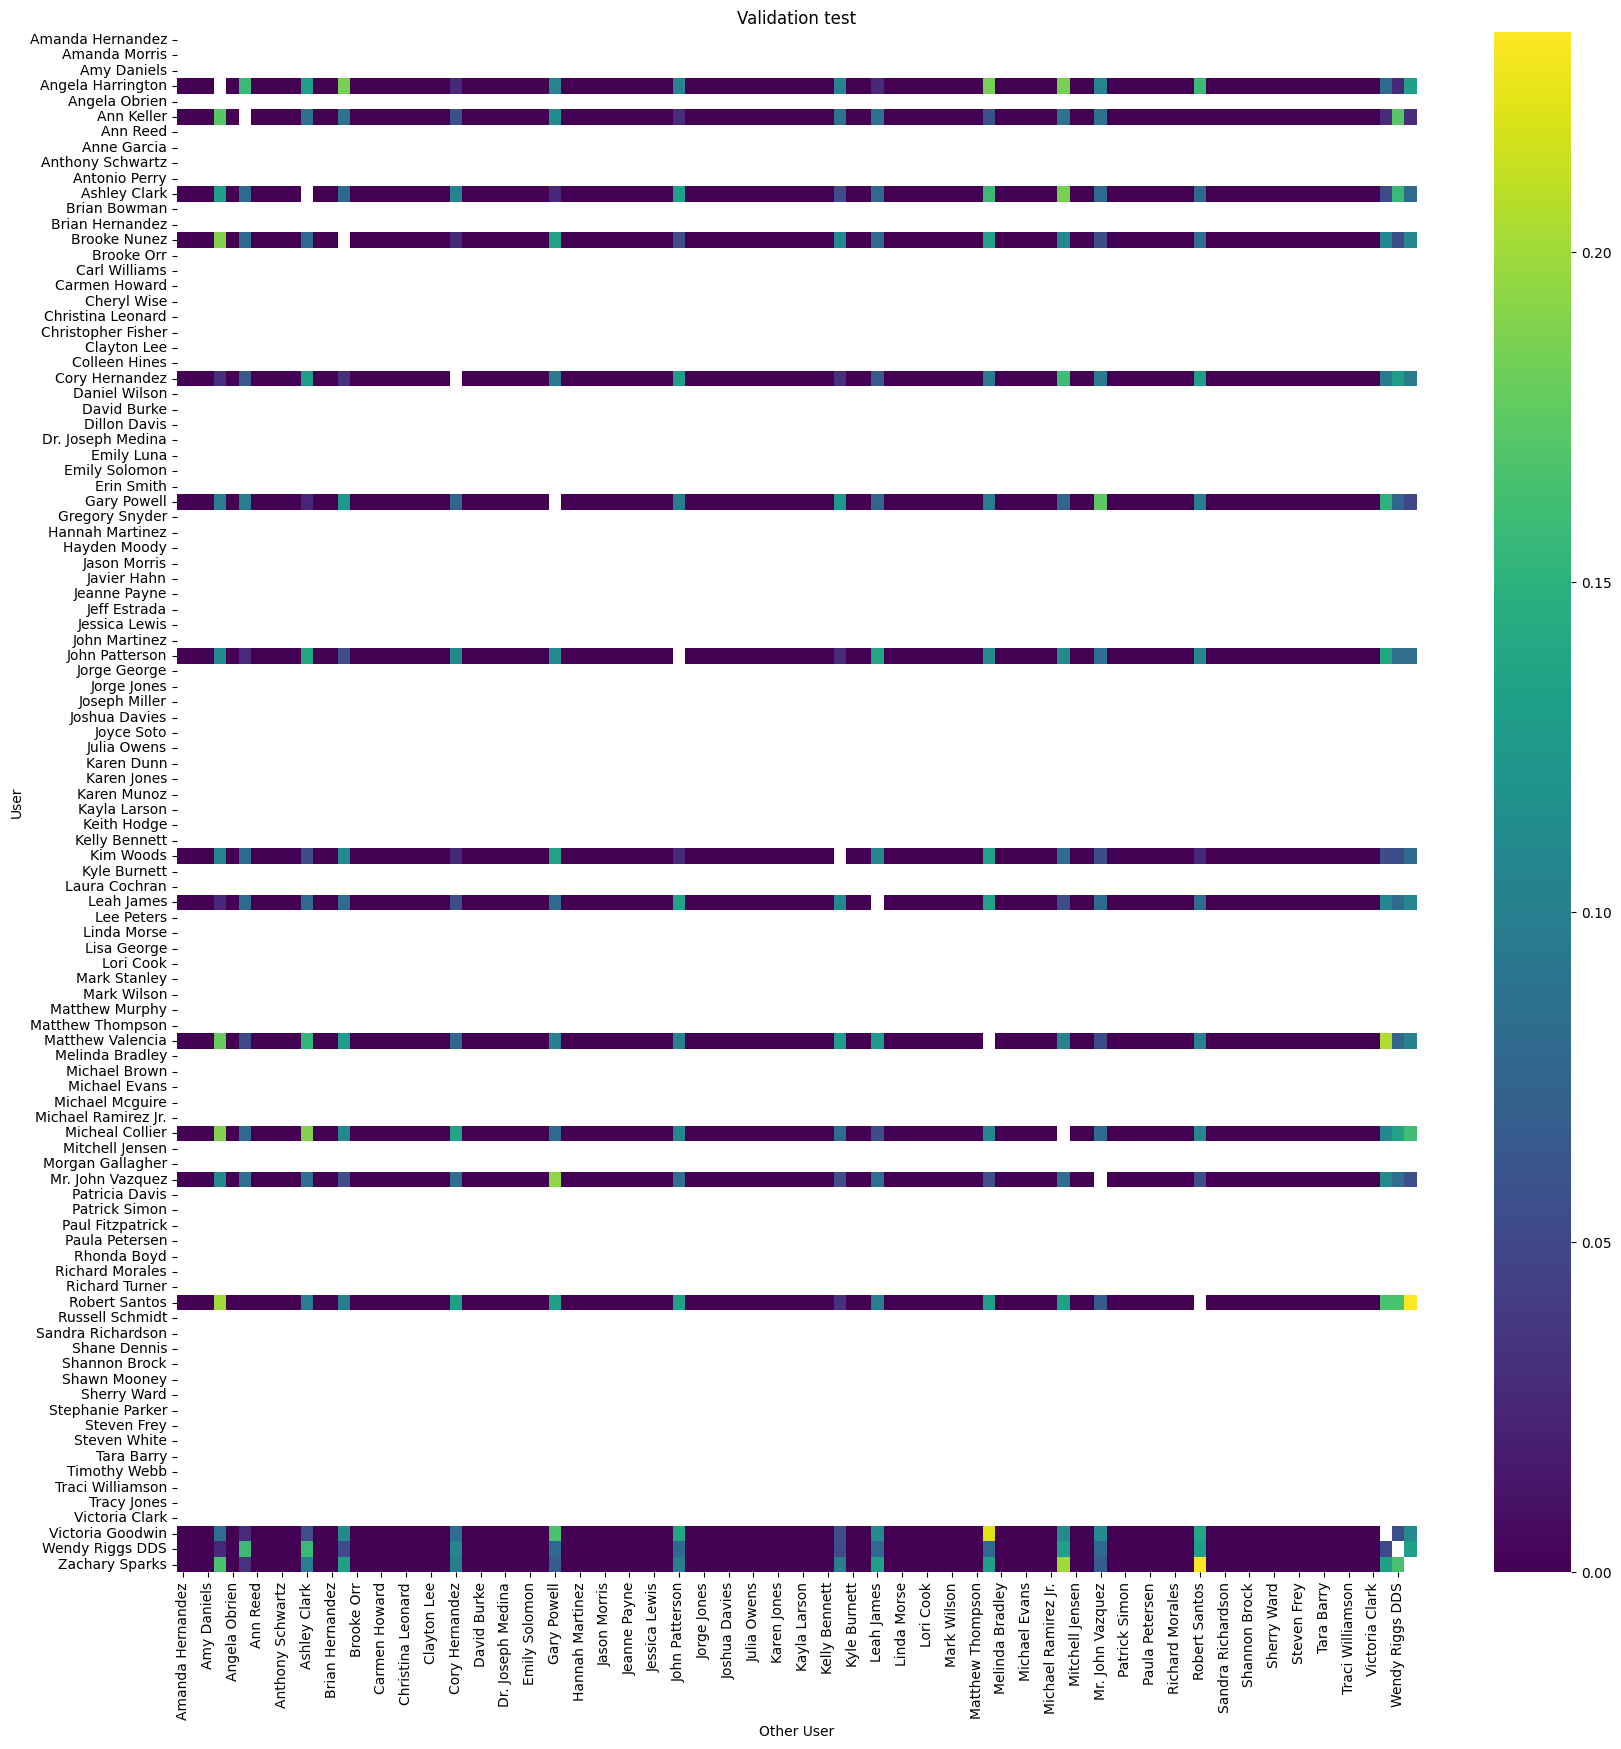

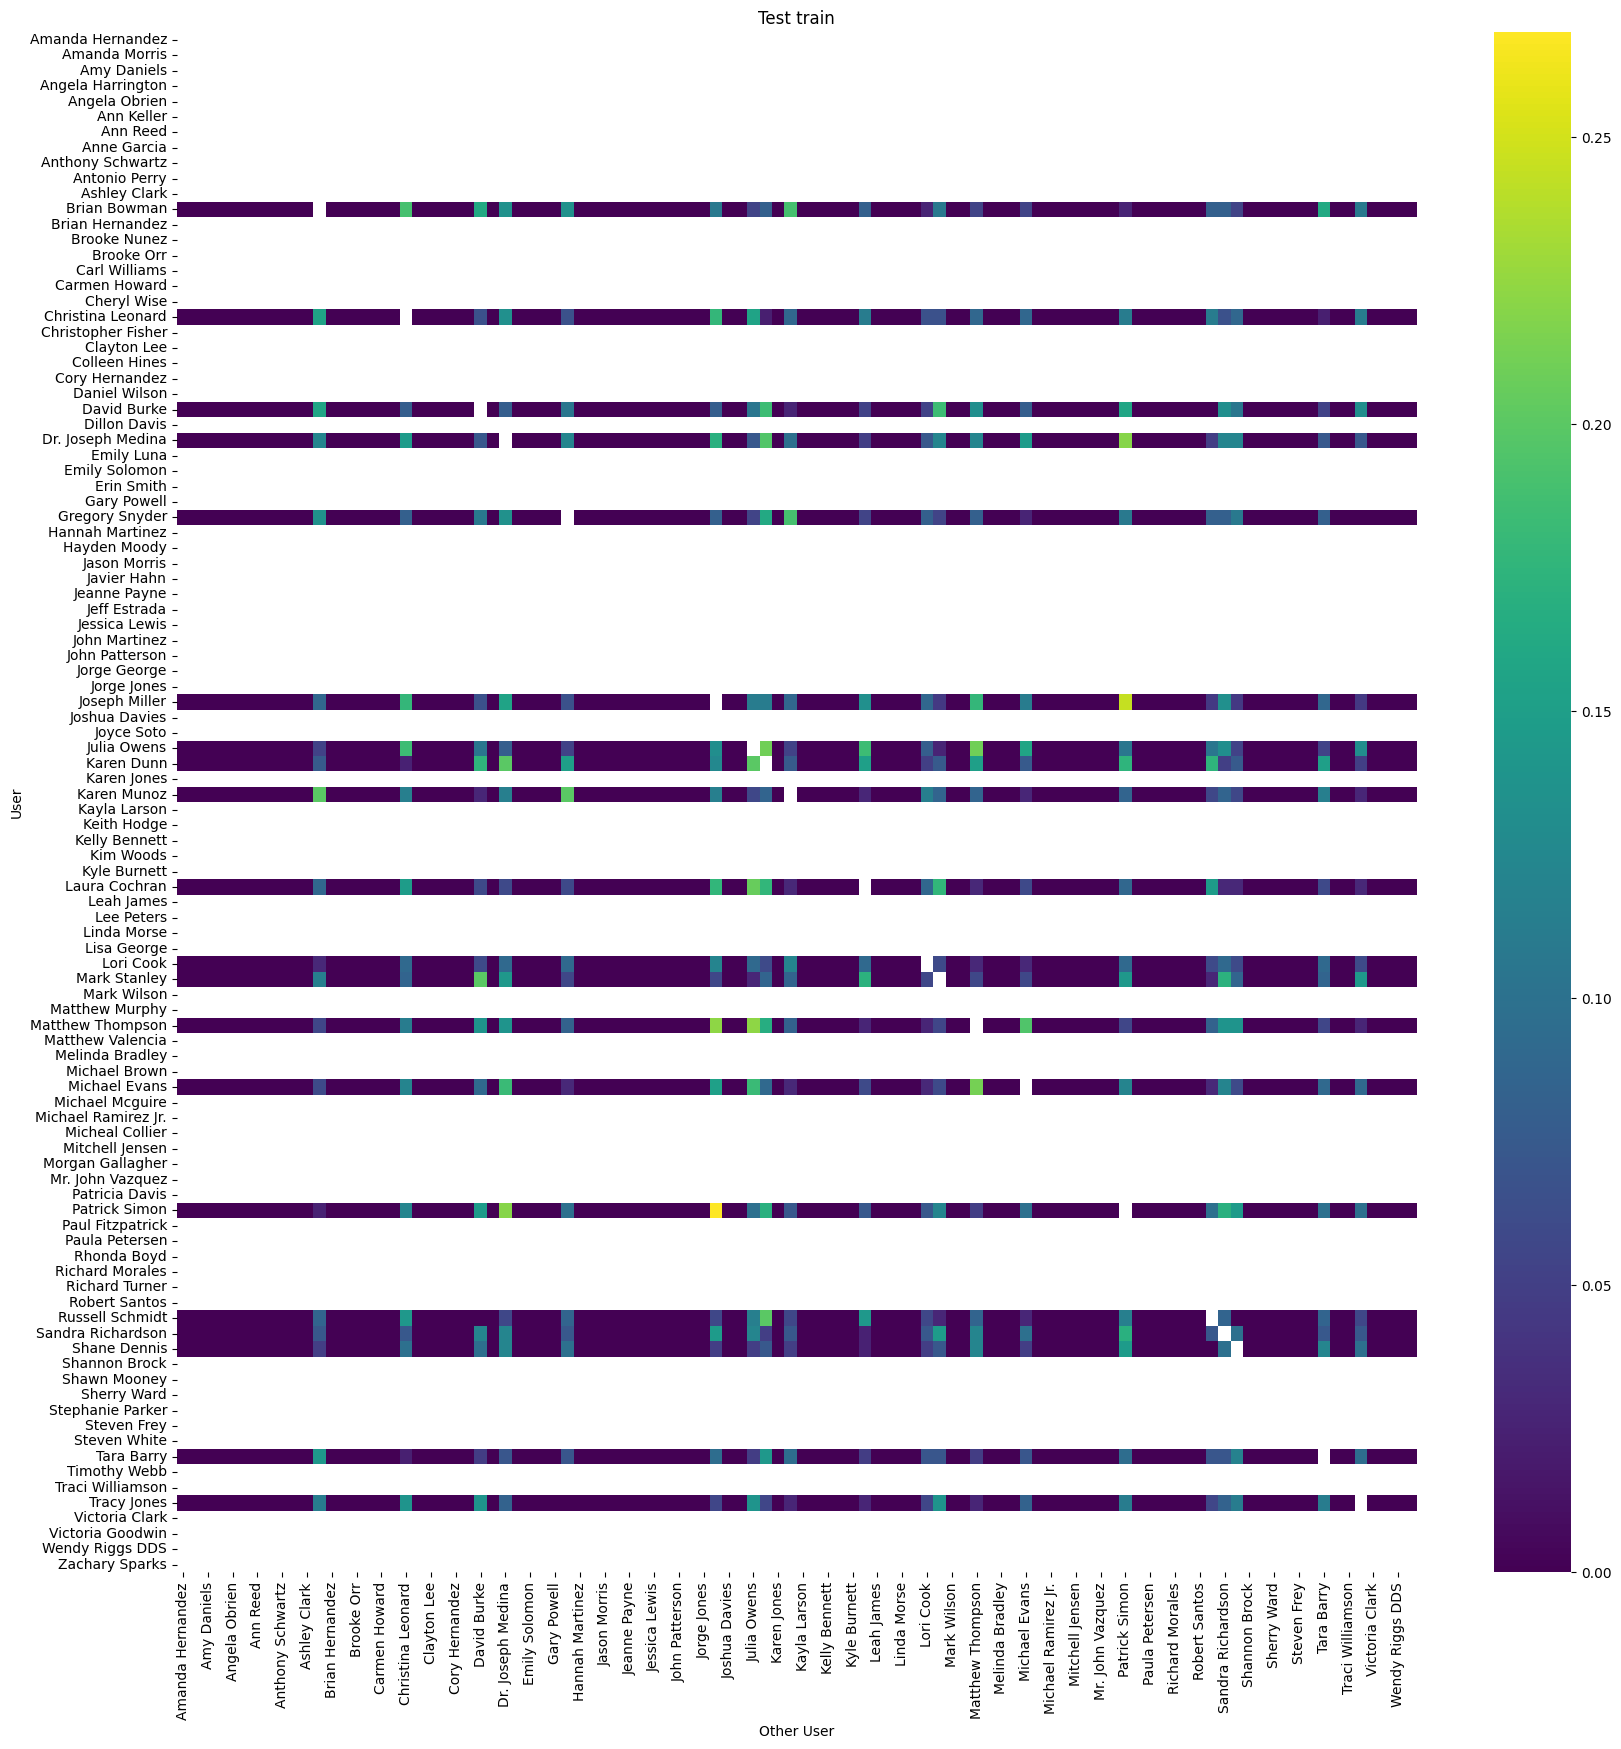

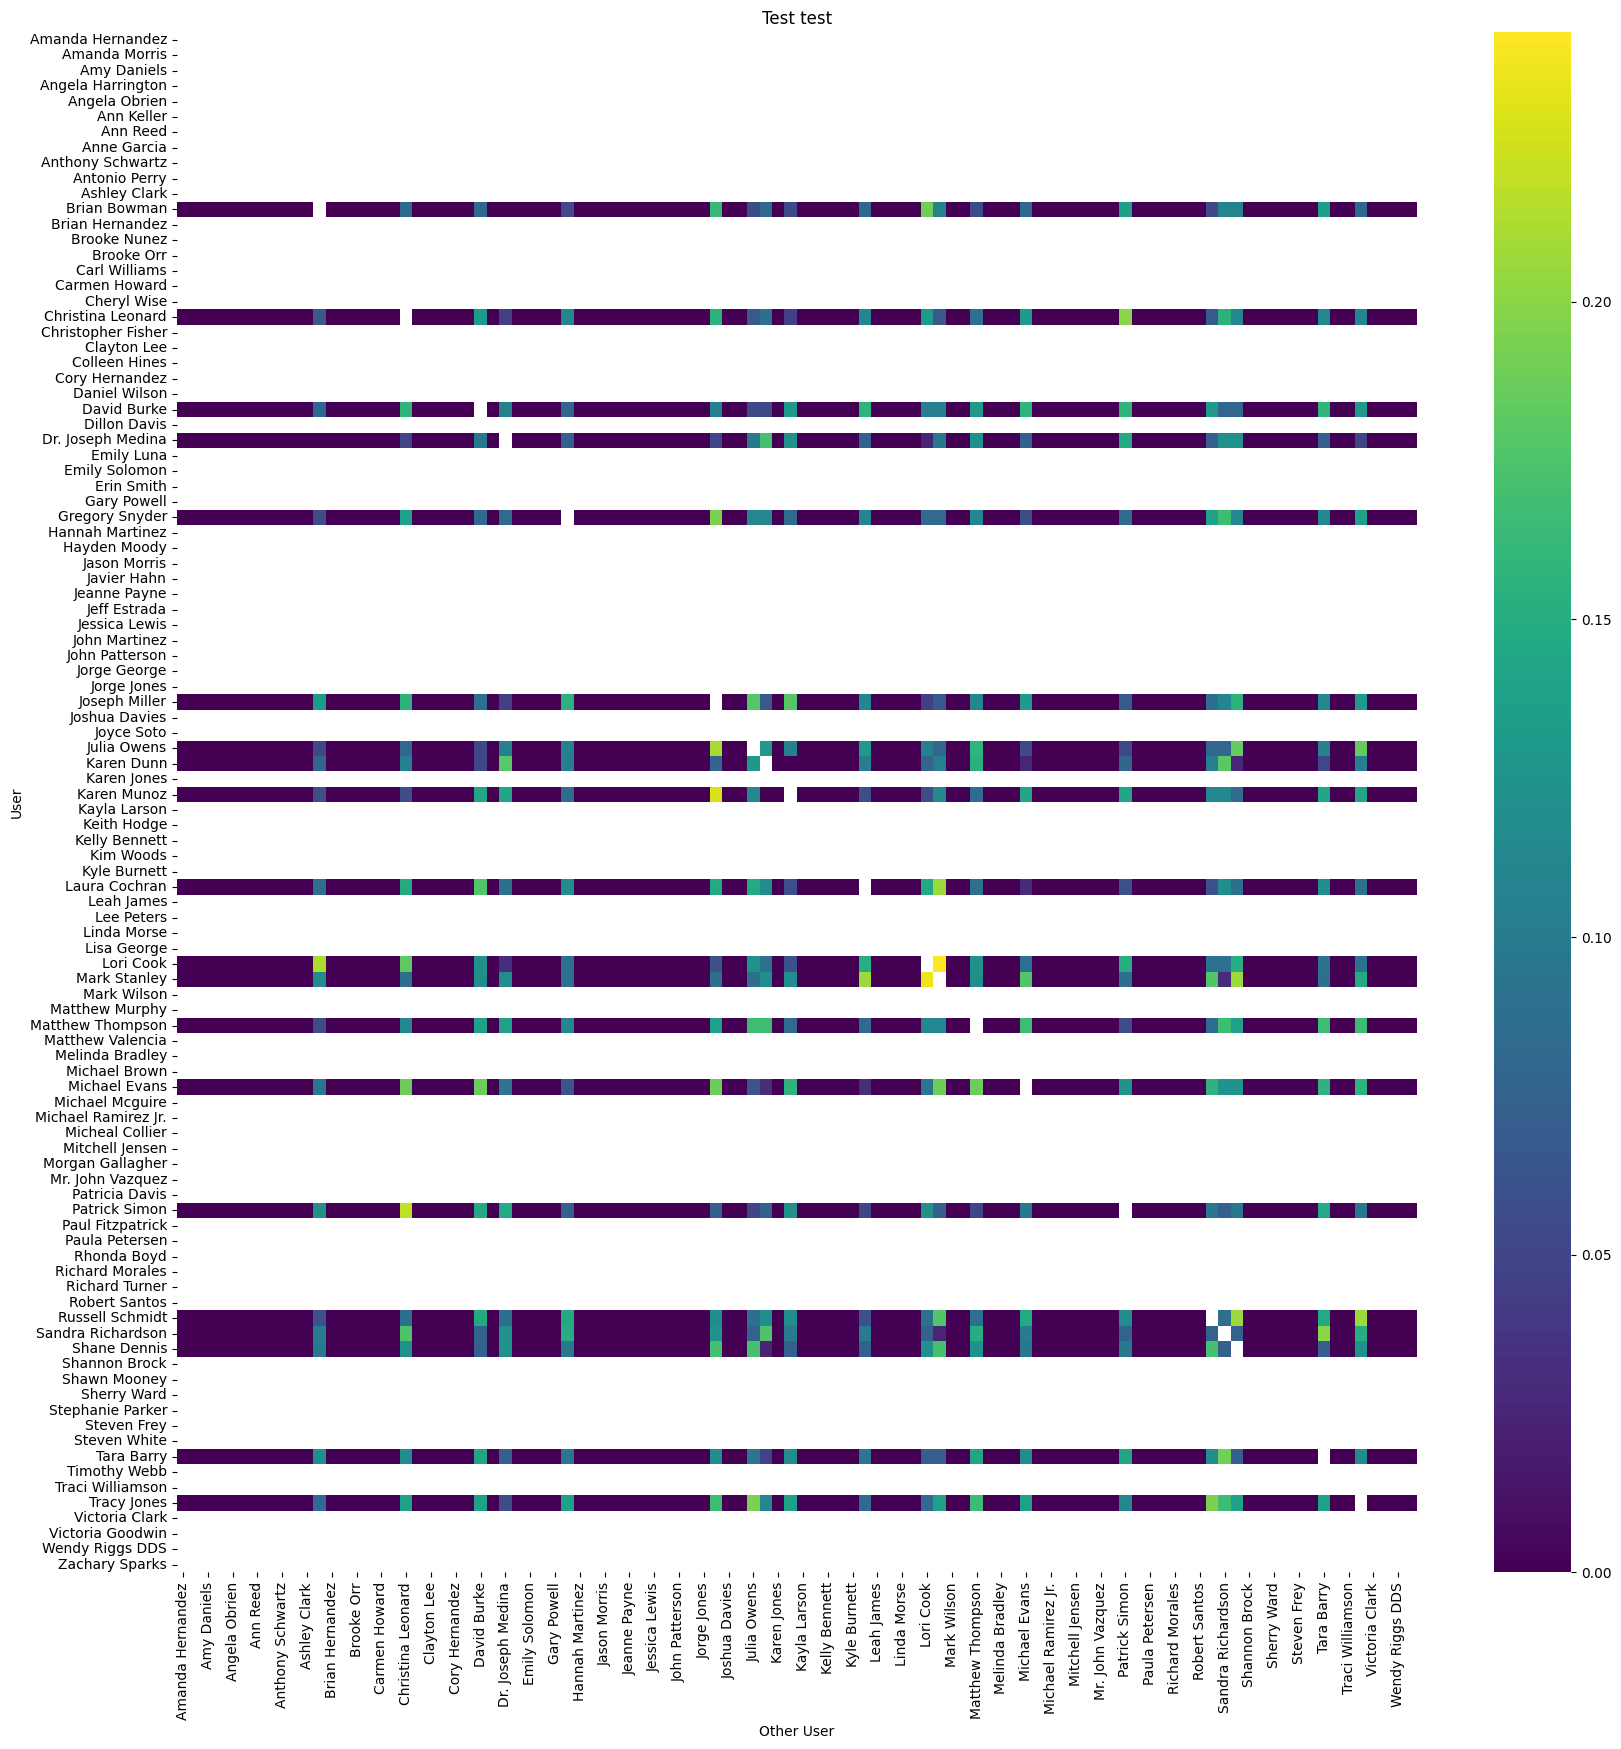

Alpha: 22.399974822998047
Min max affinity: 0.0 22.399974822998047
Min max affinity: 0.0 22.399974822998047
Min max affinity: 0.0 22.399974822998047
Min max affinity: 0.0 22.399974822998047
Min max affinity: 0.0 22.399974822998047
Min max affinity: 0.0 22.399974822998047
Max affinity: 22.399974822998047


In [12]:
train_df = df_matrix_mf_filtered[df_matrix_mf_filtered["username"].isin(train_df.index)]
# train_df["username"] = train_df["username"].cat.remove_unused_categories()
# train_df["id"] = train_df["id"].cat.remove_unused_categories()
print("Train data:")
display(train_df)

val_df_train, val_df_test = preprocessing.populate_train_test_dataframes(
    df=df_matrix_mf_filtered,
    selected_users=val_df,
    test_percentage=0.5,
    min_items_threshold=2,
)
# val_df_train["username"] = val_df_train["username"].cat.remove_unused_categories()
# val_df_test["username"] = val_df_test["username"].cat.remove_unused_categories()
# val_df_train["id"] = val_df_train["id"].cat.remove_unused_categories()
# val_df_test["id"] = val_df_test["id"].cat.remove_unused_categories()
print("Validation train data:")
display(val_df_train)
print("Validation test data:")
display(val_df_test)

test_df_train, test_df_test = preprocessing.populate_train_test_dataframes(
    df=df_matrix_mf_filtered,
    selected_users=test_df,
    test_percentage=0.5,
    min_items_threshold=2,
)
# test_df_train["username"] = test_df_train["username"].cat.remove_unused_categories()
# test_df_test["username"] = test_df_test["username"].cat.remove_unused_categories()
# test_df_train["id"] = test_df_train["id"].cat.remove_unused_categories()
# test_df_test["id"] = test_df_test["id"].cat.remove_unused_categories()
print("Test train data:")
display(test_df_train)
print("Test test data:")
display(test_df_test)

df_user_similarities = user_similarities.calculate_users_track_common_percentage(train_df, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Train")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(val_df_train, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Validation train")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(val_df_test, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Validation test")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(test_df_train, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Test train")

df_user_similarities = user_similarities.calculate_users_track_common_percentage(test_df_test, username_col="username", trackname_col="id")
plotting.plot_user_similarities_matrix(df_user_similarities, figsize=(20, 20), lower_triangle=False, title="Test test")

(
    whole_matrix_dataset,
    train_matrix_dataset,
    validation_train_matrix_dataset,
    validation_test_matrix_dataset,
    test_train_matrix_dataset,
    test_test_matrix_dataset,
) = (
    MatrixDataset(
        df=df_matrix_mf_filtered,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=train_df,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=val_df_train,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=val_df_test,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=test_df_train,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
    MatrixDataset(
        df=test_df_test,
        user_col="username",
        item_col="id",
        value_col="affinity",
        device=device,
        dtype=dtype,
    ),
)

a = whole_matrix_dataset.compute_alpha()
whole_matrix_dataset.set_alpha(a)
# min_scale, max_scale = whole_matrix_dataset.min_max_scale(bounds=(0.0, 1.0))

for dataset in [train_matrix_dataset, validation_train_matrix_dataset, validation_test_matrix_dataset, test_train_matrix_dataset, test_test_matrix_dataset]:
    dataset.set_alpha(a)
    # dataset.min_max_scale(bounds=(0.0, 1.0), optimums=(min_scale, max_scale))

print(f"Alpha: {a}")
print(f"Min max affinity: {whole_matrix_dataset.R.min().item()} {whole_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {train_matrix_dataset.R.min().item()} {train_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {validation_train_matrix_dataset.R.min().item()} {validation_train_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {validation_test_matrix_dataset.R.min().item()} {validation_test_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {test_train_matrix_dataset.R.min().item()} {test_train_matrix_dataset.R.max().item()}")
print(f"Min max affinity: {test_test_matrix_dataset.R.min().item()} {test_test_matrix_dataset.R.max().item()}")

max_affinity = whole_matrix_dataset.R.max().item()
print(f"Max affinity: {max_affinity}")

In [13]:
print("Whole dataset shape:", whole_matrix_dataset.R.shape)
print("Train dataset shape:", train_matrix_dataset.R.shape)
print("Validation train dataset shape:", validation_train_matrix_dataset.R.shape)
print("Validation test dataset shape:", validation_test_matrix_dataset.R.shape)
print("Test train dataset shape:", test_train_matrix_dataset.R.shape)
print("Test test dataset shape:", test_test_matrix_dataset.R.shape)

Whole dataset shape: torch.Size([100, 499])
Train dataset shape: torch.Size([100, 499])
Validation train dataset shape: torch.Size([100, 499])
Validation test dataset shape: torch.Size([100, 499])
Test train dataset shape: torch.Size([100, 499])
Test test dataset shape: torch.Size([100, 499])


In [14]:
whole_matrix_dataset.R

tensor([[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, 12.3725],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.5949],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  5.5735],
        [ 7.0947,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, 11.6464]],
       device='mps:0')

# Define and train the MultiVAE model

In [15]:
num_latent_factors = 200
lmf = LogisticMatrixFactorization(
    num_users=whole_matrix_dataset.R.shape[0],
    num_items=whole_matrix_dataset.R.shape[1],
    num_factors=num_latent_factors,
    reg_param=0.01,
    device=device,
    dtype=dtype,
)
lmf.to(device)

num_epochs = 30
best_model = lmf.train_model(
    R=train_matrix_dataset.R,
    validation_test=validation_test_matrix_dataset.R,
    validation_train=validation_train_matrix_dataset.R,
    num_epochs=num_epochs,
    learning_rate=0.1,
    log_interval=1,
    tqdm=False
)

Epoch: 1 	 Loss: 284804.5938 	 MPR: 0.3818 	 NDCG@100: 0.1037 	 Recall@20: 0.0656 	 Recall@50: 0.0988
Epoch: 2 	 Loss: 212309.9531 	 MPR: 0.3420 	 NDCG@100: 0.1085 	 Recall@20: 0.0625 	 Recall@50: 0.1130
Epoch: 3 	 Loss: 163405.1094 	 MPR: 0.3044 	 NDCG@100: 0.1187 	 Recall@20: 0.0750 	 Recall@50: 0.1204
Epoch: 4 	 Loss: 126677.9531 	 MPR: 0.2682 	 NDCG@100: 0.1223 	 Recall@20: 0.0719 	 Recall@50: 0.1222
Epoch: 5 	 Loss: 98953.2422 	 MPR: 0.2345 	 NDCG@100: 0.1271 	 Recall@20: 0.0812 	 Recall@50: 0.1275
Epoch: 6 	 Loss: 78442.3516 	 MPR: 0.2037 	 NDCG@100: 0.1323 	 Recall@20: 0.0812 	 Recall@50: 0.1365
Epoch: 7 	 Loss: 63299.4297 	 MPR: 0.1782 	 NDCG@100: 0.1291 	 Recall@20: 0.0906 	 Recall@50: 0.1402
Epoch: 8 	 Loss: 52138.1719 	 MPR: 0.1568 	 NDCG@100: 0.1323 	 Recall@20: 0.0938 	 Recall@50: 0.1398
Epoch: 9 	 Loss: 43811.0547 	 MPR: 0.1393 	 NDCG@100: 0.1332 	 Recall@20: 0.1031 	 Recall@50: 0.1435
Epoch: 10 	 Loss: 37517.5977 	 MPR: 0.1246 	 NDCG@100: 0.1357 	 Recall@20: 0.1000 	 Rec

In [16]:
losses_df = pd.DataFrame(
    [
        lmf.losses.cpu().numpy(),
        lmf.validation_losses.cpu().numpy(),
        lmf.ndcg_history.cpu().numpy(),
        lmf.recall20_history.cpu().numpy(),
        lmf.recall50_history.cpu().numpy(),
        lmf.mpr_history.cpu().numpy(),
    ]
).T
losses_df.columns = ["loss", "validation_loss", "ndcg", "r20", "r50", "mpr"]

px.line(
    losses_df, x=losses_df.index, y=["loss", "validation_loss"], title="Loss"
).show()
px.line(losses_df, x=losses_df.index, y=["ndcg", "r20", "r50", "mpr"], title="Metrics").show()

In [17]:
total_loss, ndcg, recall_20, recall_50, mpr = best_model.evaluate_model(
    R=whole_matrix_dataset.R,
    validation_test=validation_test_matrix_dataset.R,
    validation_train=validation_train_matrix_dataset.R
)
print(f"Total loss: {total_loss}")
print(f"NDCG_100: {ndcg}")
print(f"Recall_20: {recall_20}")
print(f"Recall_50: {recall_50}")
print(f"MPR: {mpr}")

Total loss: 52176.5859375
NDCG_100: 0.14294180274009705
Recall_20: 0.125
Recall_50: 0.16090062260627747
MPR: 0.21402330696582794
